In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nishanthkv/netflix/netflix_titles.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/nishanthkv/netflix/netflix_titles.csv')

In [3]:
df.shape

(6234, 12)

## OVERVIEW OF NETFILX DATA

![failed to load](https://fdn.gsmarena.com/imgroot/news/20/10/netflix-india-free-weekend/-1200/gsmarena_001.jpg)


The Netflix dataset you are working on is a collection of information about movies and TV shows available on Netflix. It contains details such as the title, type of content, director, cast, country, release year, rating, duration, genre, and description of each show or movie. The dataset is very useful for Exploratory Data Analysis (EDA) because it helps in understanding Netflix content trends, audience preferences, popular genres, and the growth of movies and TV shows over the years. By analyzing this dataset, we can identify patterns such as which countries produce more Netflix content, whether Netflix focuses more on movies or TV shows, and how content additions changed over time.

### Simple Points About the Dataset

* The dataset contains information about Netflix movies and TV shows.
* It includes both Movies and TV Shows in one file.
* Each row represents one Netflix title.
* Important columns include:

  * `title` → Name of the movie/show
  * `type` → Movie or TV Show
  * `director` → Director name
  * `cast` → Actors involved
  * `country` → Country of production
  * `date_added` → Date added to Netflix
  * `release_year` → Year released
  * `rating` → Age rating (TV-MA, PG, etc.)
  * `duration` → Length of movie or number of seasons
  * `listed_in` → Genre/category
  * `description` → Short summary
* The dataset is suitable for:

  * Data Cleaning
  * Data Visualization
  * Trend Analysis
  * Genre Analysis
  * Country-wise Analysis
  * Recommendation System projects
* It helps beginners practice EDA using Python libraries like Pandas, Matplotlib, and Seaborn.
* The dataset contains missing values, which makes it useful for learning data preprocessing techniques.

In [4]:
# importing libraries

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#additional libraries
import warnings
warnings.filterwarnings("ignore")

In [5]:
#sample view of data set

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


## DATA CARDS ON NETFLIX DATA


| Feature Name | Description                 |
| ------------ | --------------------------- |
| show_id      | Unique ID of each content   |
| type         | Category (Movie or TV Show) |
| title        | Name of the movie/show      |
| director     | Director name               |
| cast         | Actors/Actresses involved   |
| country      | Production country          |
| date_added   | Date added to Netflix       |
| release_year | Year of release             |
| rating       | Audience age rating         |
| duration     | Runtime or seasons          |
| listed_in    | Genre/category              |
| description  | Short summary of content    |


## Summarized Values of the Netflix Dataset

* **Dataset Name:** Netflix Movies and TV Shows
* **Total Records:** Around 8,800+ entries
* **Content Types:** Movies and TV Shows
* **Main Columns:** 12
* **Popular Features:** Title, Director, Cast, Country, Rating, Duration, Genre
* **Data Type:** Mixed (Categorical and Numerical)
* **Most Common Content:** Movies
* **Analysis Purpose:** Trend Analysis and Visualization
* **Contains Missing Values:** Yes

In [6]:
# duplicate entries
df.duplicated().sum()

np.int64(0)

This data set has no dublicate values

In [7]:
#null cells
df.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


In [9]:
# filtering out the movies
movies_df = df[df['type'] == 'Movie'].reset_index(drop = True)

# filtering out the seasons
tv_shows_df = df[df['type'] == 'TV Show'].reset_index(drop = True)


In [10]:
movies_df.shape

(4265, 12)

In [11]:
movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...
3,70304989,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada","September 8, 2017",2014,R,110 min,"International Movies, Sci-Fi & Fantasy, Thrillers","In a dystopian future, an insurance adjuster f..."
4,80164077,Movie,Fabrizio Copano: Solo pienso en mi,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile,"September 8, 2017",2017,TV-MA,60 min,Stand-Up Comedy,Fabrizio Copano takes audience participation t...


In [12]:
tv_shows_df.shape

(1969, 12)

In [13]:
tv_shows_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
1,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
2,80163890,TV Show,Apaches,NaN,"Alberto Ammann, Eloy Azorín, Verónica Echegui,...",Spain,"September 8, 2017",2016,TV-MA,1 Season,"Crime TV Shows, International TV Shows, Spanis...",A young journalist is forced into a life of cr...
3,80117902,TV Show,Fire Chasers,NaN,NaN,United States,"September 8, 2017",2017,TV-MA,1 Season,"Docuseries, Science & Nature TV","As California's 2016 fire season rages, brave ..."
4,80244601,TV Show,Castle of Stars,NaN,"Chaiyapol Pupart, Jintanutda Lummakanon, Worra...",NaN,"September 7, 2018",2015,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...",As four couples with different lifestyles go t...


## Converting the movies_df and tv_shows_df data set to of column "Duration" to integer from object

In [14]:
# extracted the numbers safely by using regex

movies_df['duration'] = movies_df['duration'].astype(str).str.extract(r'(\d+)')
tv_shows_df['duration'] = tv_shows_df['duration'].astype(str).str.extract(r'(\d+)')

In [15]:
# now converting the extracted values to integers

movies_df['duration'] = pd.to_numeric(movies_df['duration'], errors='coerce').astype('Int64')
tv_shows_df['duration'] = pd.to_numeric(tv_shows_df['duration'], errors='coerce').astype('Int64')

In [16]:
#seeking description for movies
movies_df.describe()

,show_id,release_year,duration
count,4.265000e+03,4265.000000,4265.0
mean,7.562096e+07,2012.354279,99.100821
std,1.287630e+07,9.735306,28.074857
min,2.477470e+05,1942.000000,3.0
25%,7.030419e+07,2012.000000,86.0
50%,8.015858e+07,2016.000000,98.0
75%,8.099157e+07,2017.000000,115.0
max,8.123573e+07,2020.000000,312.0


In [17]:
# seeking description for tv_shows
tv_shows_df.describe()

,show_id,release_year,duration
count,1.969000e+03,1969.000000,1969.0
mean,7.904892e+07,2015.536313,1.779584
std,3.462549e+06,5.799568,1.624936
min,6.003679e+07,1925.000000,1.0
25%,8.009178e+07,2015.000000,1.0
50%,8.017572e+07,2017.000000,1.0
75%,8.023986e+07,2018.000000,2.0
max,8.123560e+07,2020.000000,15.0


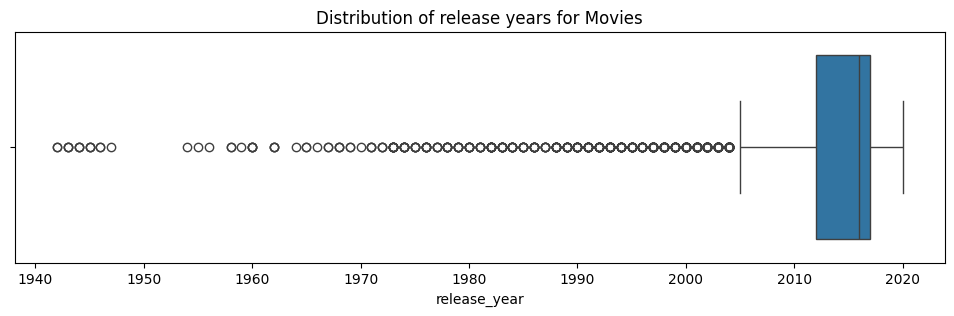

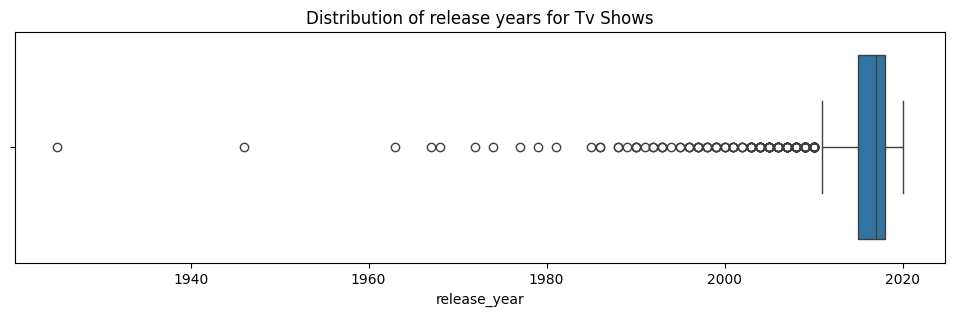

In [18]:
#univariate analysis in box plot
plt.figure(figsize = (12,3))
sns.boxplot(data = movies_df, x = 'release_year')
plt.title("Distribution of release years for Movies")
plt.show()


plt.figure(figsize = (12,3))
sns.boxplot(data = tv_shows_df, x = 'release_year')
plt.title("Distribution of release years for Tv Shows")
plt.show()

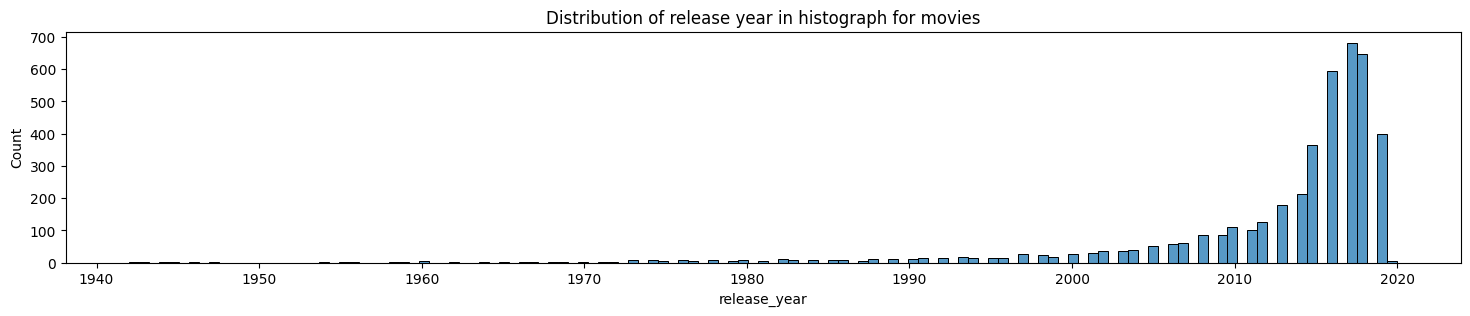

level of skewness 	 -3.7047455264807008


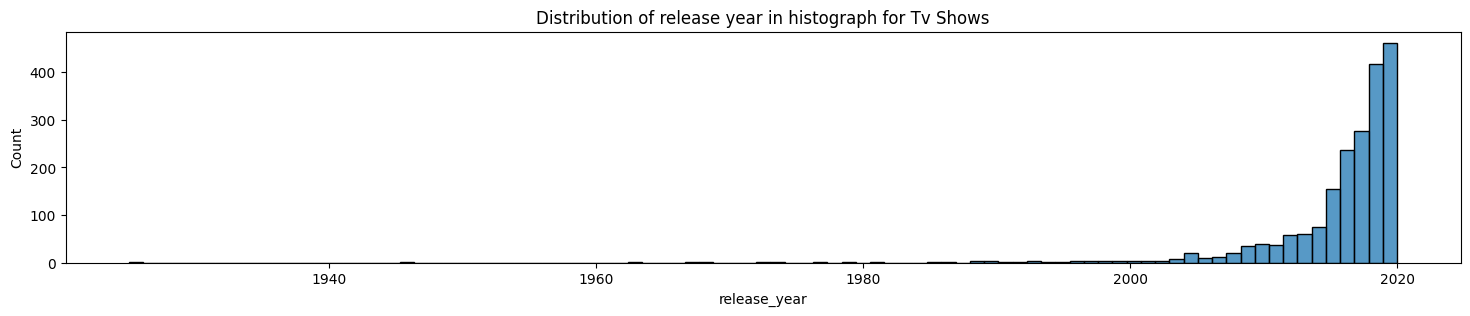

level of skewness 	 -3.7047455264807008


In [19]:
#univariate analysis in histograph
plt.figure(figsize = (18,3))
sns.histplot(data = movies_df, x = "release_year")
plt.title("Distribution of release year in histograph for movies")
plt.show()
print("level of skewness \t", df.release_year.skew())


plt.figure(figsize = (18,3))
sns.histplot(data = tv_shows_df, x = "release_year")
plt.title("Distribution of release year in histograph for Tv Shows")
plt.show()

print("level of skewness \t", df.release_year.skew())

In [20]:
# Inter quartile range for movies

m_q1 = movies_df.release_year.quantile(0.25)
m_q2 = movies_df.release_year.quantile(0.50)
m_q3 = movies_df.release_year.quantile(0.75)
iqr = m_q3 - m_q1

uf = m_q3 + 1.5 * iqr
lf = m_q1 - 1.5 * iqr
print("fence for Movies")
print("upper fence \t", uf)
print("lower fence \t", lf)

print("-"* 120)


#Inter quartile range for TV_shows

s_q1 = tv_shows_df.release_year.quantile(0.25)
s_q2 = tv_shows_df.release_year.quantile(0.50)
s_q3 = tv_shows_df.release_year.quantile(0.75)
iqr = s_q3 - s_q1

uf = s_q3 + 1.5 * iqr
lf = s_q1 - 1.5 * iqr
print("fence for Movies")
print("upper fence \t", uf)
print("lower fence \t", lf)

fence for Movies
upper fence 	 2024.5
lower fence 	 2004.5
------------------------------------------------------------------------------------------------------------------------
fence for Movies
upper fence 	 2022.5
lower fence 	 2010.5


The lower fence is around 2005, meaning movies released before 2005 are treated as outliers due to their comparatively lower frequency in the dataset.

This indicates that the number of movie releases significantly increased after 2005, showing rapid growth in the entertainment industry.

One possible reason for this growth could be the rise of CDs, DVDs, digital media, and online distribution platforms, which made content production and accessibility easier.

The data also shows a right-skewed distribution, suggesting that most Netflix content belongs to recent years, while older movies are comparatively fewer in number.

In [21]:
# null values for movies

movies_df.isnull().sum()

show_id           0
type              0
title             0
director        128
cast            360
country         195
date_added        1
release_year      0
rating            8
duration          0
listed_in         0
description       0
dtype: int64

The dataset contains missing values mainly in:

director → 128 missing values

cast → 360 missing values

country → 195 missing values

date_added → 1 missing values

rating → 8 missing values

Columns such as show_id, type, title, release_year, duration, genres, and description contain complete data with no missing values.

In [22]:
# null values for tv_shows

tv_shows_df.isnull().sum()

show_id            0
type               0
title              0
director        1841
cast             210
country          281
date_added        10
release_year       0
rating             2
duration           0
listed_in          0
description        0
dtype: int64

The dataset contains missing values mainly in:

director → 1841 missing values

cast → 210 missing values

country → 281 missing values

date_added → 10 missing values

rating → 2 missing values

Columns such as show_id, type, title, release_year, duration, genres, and description contain complete data with no missing values.

In [23]:
#null values in % for movies

movies_df.isnull().mean()* 100

show_id         0.000000
type            0.000000
title           0.000000
director        3.001172
cast            8.440797
country         4.572098
date_added      0.023447
release_year    0.000000
rating          0.187573
duration        0.000000
listed_in       0.000000
description     0.000000
dtype: float64

In [24]:
#null values in % for movies

tv_shows_df.isnull().mean()* 100

show_id          0.000000
type             0.000000
title            0.000000
director        93.499238
cast            10.665312
country         14.271204
date_added       0.507872
release_year     0.000000
rating           0.101574
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

# GOLDEN RULE! 

# null values<5% --> mean, median and mode 
# null values>5% --> try to find some patterns / knn imputers
# null values>50% --> drop that column

In [25]:
movies_df.rating.fillna(movies_df.rating.mode().values[0], inplace = True)
movies_df.date_added.fillna(movies_df.date_added.mode().values[0], inplace = True)
movies_df.country.fillna(movies_df.country.mode().values[0], inplace = True)


tv_shows_df.rating.fillna(tv_shows_df.rating.mode().values[0], inplace = True)
tv_shows_df.date_added.fillna(tv_shows_df.date_added.mode().values[0], inplace = True)
tv_shows_df.country.fillna(tv_shows_df.country.mode().values[0], inplace = True)

In [26]:
# 
movies_df.isnull().sum()[movies_df.isnull().sum()>0]

director    128
cast        360
dtype: int64

In [27]:
tv_shows_df.isnull().sum()[tv_shows_df.isnull().sum()>0]

director    1841
cast         210
dtype: int64

In [28]:
movies_df.director.fillna('unknown', inplace = True)
movies_df.cast.fillna('unknown', inplace = True)

In [29]:
tv_shows_df.director.fillna('unknown', inplace = True)
tv_shows_df.cast.fillna('unknown', inplace = True)

In [30]:
# again checking for null values after replacing director and cast with unknown

movies_df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [31]:
tv_shows_df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## Exploratory Data Analysis

In [32]:
#movies
custome_col_1 = movies_df[["release_year", "duration"]].describe(include = 'all')
num_movie = list(custome_col_1.columns)

cat_movie = []

for i in movies_df.columns:
    if i not in num_movie:
        cat_movie.append(i)

print("numerical cols : \t", num_movie)
print("categorical cols : \t", cat_movie)

numerical cols : 	 ['release_year', 'duration']
categorical cols : 	 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'listed_in', 'description']


In [33]:
# tv_shows
custome_col_2 = tv_shows_df[["release_year", "duration"]].describe(include = 'all')
num_show = list(custome_col_2.columns)

cat_show = []

for i in tv_shows_df.columns:
    if i not in num_show:
        cat_show.append(i)

print("numerical cols : \t", num_show)
print("categorical cols : \t", cat_show)

numerical cols : 	 ['release_year', 'duration']
categorical cols : 	 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'listed_in', 'description']


In [34]:
# pie chart of type

temp_type = df.type.value_counts().reset_index()

temp_type

fig = px.pie(
    temp_type,
    names='type',
    values='count',
    hole=0.5,
    title='Distribution of Movies and TV Shows on Netflix',
    color='type',
    color_discrete_map={
        'Movie': '#E50914',     # Netflix Red
        'TV Show': '#1F77B4'    # Blue
    }
)

# Layout Improvements
fig.update_traces(
    textinfo='percent+label',
    pull=[0.03, 0.03],
    marker=dict(line=dict(color='white', width=2))
)

fig.update_layout(
    title_x=0.5,
    template='plotly_white',
    font=dict(size=14),
    legend_title='Content Type'
)
fig.show()

Movies contribute nearly 68% of the total Netflix content library, while TV Shows account for approximately 32%.

This indicates that Netflix primarily focuses on movie-based entertainment, with movies dominating the platform’s overall catalog.

Comparatively, the number of TV Shows is significantly lower, suggesting that Netflix contains a much larger collection of films than episodic content.

In [35]:
# movies
temp_director_movies = movies_df.director.value_counts().sort_values(ascending = False).drop('unknown')
temp_director_movies.head(10).reset_index()

,director,count
0,"Raúl Campos, Jan Suter",18
1,Marcus Raboy,14
2,Jay Karas,13
3,Jay Chapman,12
4,Steven Spielberg,9
5,Martin Scorsese,9
6,Lance Bangs,8
7,David Dhawan,8
8,Johnnie To,8
9,Ryan Polito,7


In [36]:
# tv_shows
temp_director_shows = tv_shows_df.director.value_counts().sort_values(ascending = False).drop('unknown')
temp_director_shows.head(10).reset_index()

,director,count
0,Alastair Fothergill,3
1,Iginio Straffi,2
2,Stan Lathan,2
3,Ken Burns,2
4,Shin Won-ho,2
5,Rob Seidenglanz,2
6,Ahmet Katıksız,1
7,Park Joon-hwa,1
8,Mark Tonderai,1
9,Padraic McKinley,1


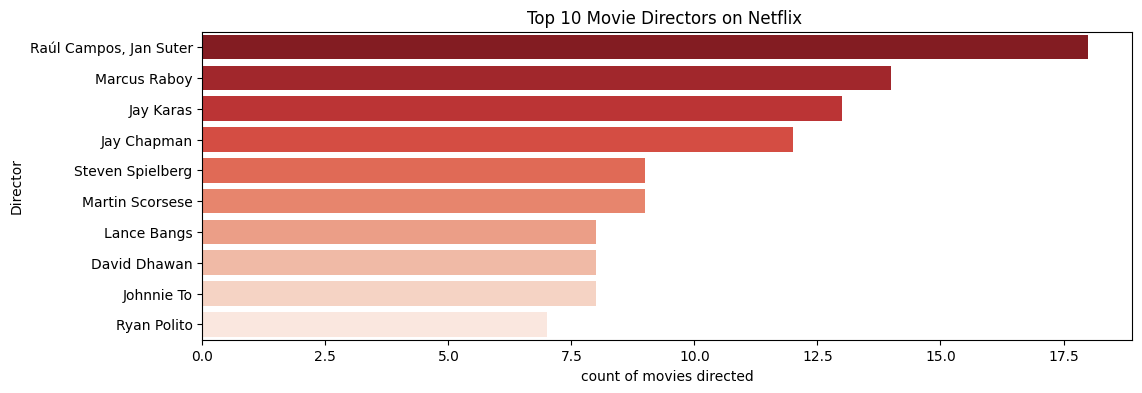

In [37]:
# now seeing the top 10 directors excluding the "unknown" for Movies
top_directors_movies = temp_director_movies.head(10).reset_index()
plt.figure(figsize = (12, 4))
sns.barplot(data = top_directors_movies, x = "count", y = "director", palette = 'Reds_r' )
plt.title("Top 10 Movie Directors on Netflix ")
plt.xlabel("count of movies directed")
plt.ylabel("Director")
plt.show()

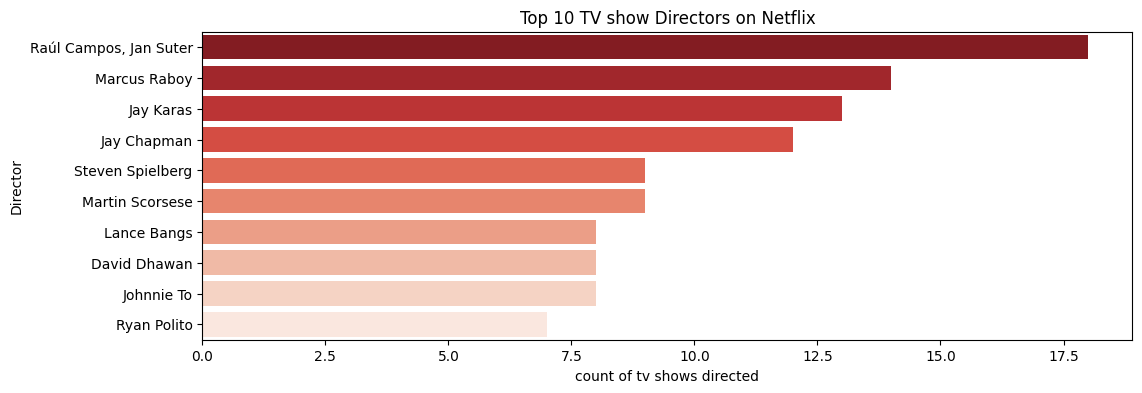

In [38]:
## now seeing the top 10 directors excluding the "unknown" for tv shows
top_directors_shows = temp_director_movies.head(10).reset_index()
plt.figure(figsize = (12, 4))
sns.barplot(data = top_directors_shows, x = "count", y = "director", palette = 'Reds_r')
plt.title("Top 10 TV show Directors on Netflix")
plt.xlabel("count of tv shows directed")
plt.ylabel("Director")
plt.show()

In [39]:
# seeing for the movies that a single cast has done
movies_df.cast.str.split(',', expand = True)

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,Alan Marriott,Andrew Toth,Brian Dobson,Cole Howard,Jennifer Cameron,Jonathan Holmes,Lee Tockar,Lisa Durupt,Maya Kay,Michael Dobson,...,None,None,None,None,None,None,None,None,None,None
1,Jandino Asporaat,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,Nesta Cooper,Kate Walsh,John Michael Higgins,Keith Powers,Alicia Sanz,Jake Borelli,Kid Ink,Yousef Erakat,Rebekah Graf,Anne Winters,...,None,None,None,None,None,None,None,None,None,None
3,Antonio Banderas,Dylan McDermott,Melanie Griffith,Birgitte Hjort Sørensen,Robert Forster,Christa Campbell,Tim McInnerny,Andy Nyman,David Ryall,None,...,None,None,None,None,None,None,None,None,None,None
4,Fabrizio Copano,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4260,unknown,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4261,Rene Russo,Oliver Platt,Johnny Simmons,Jane Levy,Marc Maron,Ron Myles,Jessica Garrison,Fabianne Therese,None,None,...,None,None,None,None,None,None,None,None,None,None
4262,Allen Iverson,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4263,Jeremy Scott,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [40]:
# seeing for the tv shows that a single cast has done
tv_shows_df.cast.str.split(',', expand = True)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,Peter Cullen,Sumalee Montano,Frank Welker,Jeffrey Combs,Kevin Michael Richardson,Tania Gunadi,Josh Keaton,Steve Blum,Andy Pessoa,Ernie Hudson,...,None,None,None,None,None,None,None,None,None,None
1,Will Friedle,Darren Criss,Constance Zimmer,Khary Payton,Mitchell Whitfield,Stuart Allan,Ted McGinley,Peter Cullen,None,None,...,None,None,None,None,None,None,None,None,None,None
2,Alberto Ammann,Eloy Azorín,Verónica Echegui,Lucía Jiménez,Claudia Traisac,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,unknown,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,Chaiyapol Pupart,Jintanutda Lummakanon,Worrawech Danuwong,Ornjira Lamwilai,Yong Armchair,Keerati Mahapreukpong,Akarat Nimitchai,Kornpassorn Duaysianklao,Nattapong Chartpong,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,Igor Dmitriev,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1965,Burnie Burns,Jason Saldaña,Gustavo Sorola,Geoff Lazer Ramsey,Joel Heyman,Matt Hullum,Dan Godwin,Kathleen Zuelch,Yomary Cruz,Nathan Zellner,...,None,None,None,None,None,None,None,None,None,None
1966,Marc Maron,Judd Hirsch,Josh Brener,Nora Zehetner,Andy Kindler,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1967,Daniel Radcliffe,Jon Hamm,Adam Godley,Christopher Godwin,Rosie Cavaliero,Vicki Pepperdine,Margaret Clunie,Tim Steed,Shaun Pye,None,...,None,None,None,None,None,None,None,None,None,None


In [41]:
movies_df.cast.str.split(',', expand = True).iloc[:,0:2]

,0,1
0,Alan Marriott,Andrew Toth
1,Jandino Asporaat,None
2,Nesta Cooper,Kate Walsh
3,Antonio Banderas,Dylan McDermott
4,Fabrizio Copano,None
...,...,...
4260,unknown,None
4261,Rene Russo,Oliver Platt
4262,Allen Iverson,None
4263,Jeremy Scott,None


In [42]:
tv_shows_df.cast.str.split(',', expand = True).iloc[:,0:2]

,0,1
0,Peter Cullen,Sumalee Montano
1,Will Friedle,Darren Criss
2,Alberto Ammann,Eloy Azorín
3,unknown,None
4,Chaiyapol Pupart,Jintanutda Lummakanon
...,...,...
1964,Igor Dmitriev,None
1965,Burnie Burns,Jason Saldaña
1966,Marc Maron,Judd Hirsch
1967,Daniel Radcliffe,Jon Hamm


In [43]:
temp_lead_movies = movies_df.cast.str.split(',', expand = True)[0].value_counts().drop('unknown').head(15).reset_index().rename({0:'lead_movie_actor', 'count' : 'no_movies'}, axis = 1)

In [44]:
temp_lead_tv_shows = tv_shows_df.cast.str.split(',', expand = True)[0].value_counts().drop('unknown').head(15).reset_index().rename({0:'lead_tv_show_actor', 'count' : 'no_tv_shows'}, axis = 1)

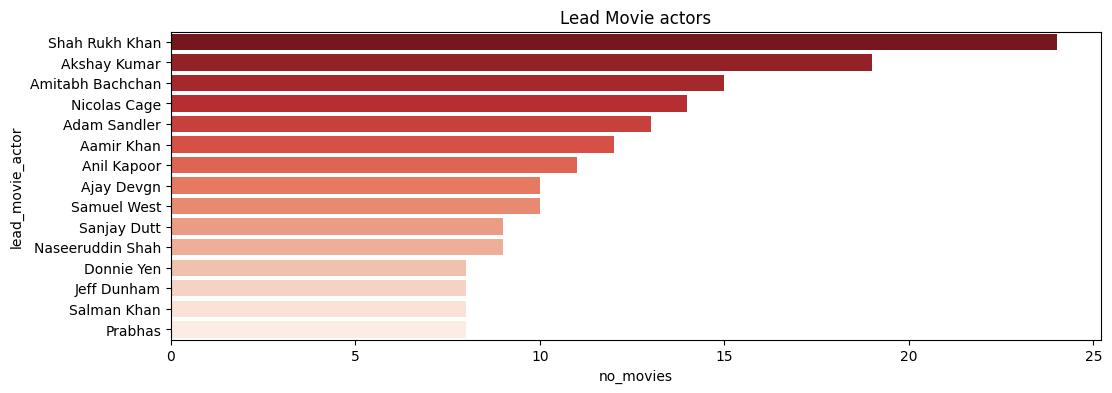

In [45]:
# barchart on movies for lead actors
plt.figure(figsize = (12, 4))
sns.barplot(data = temp_lead_movies, y = 'lead_movie_actor', x = 'no_movies', palette = 'Reds_r')
plt.title("Lead Movie actors")
plt.show()

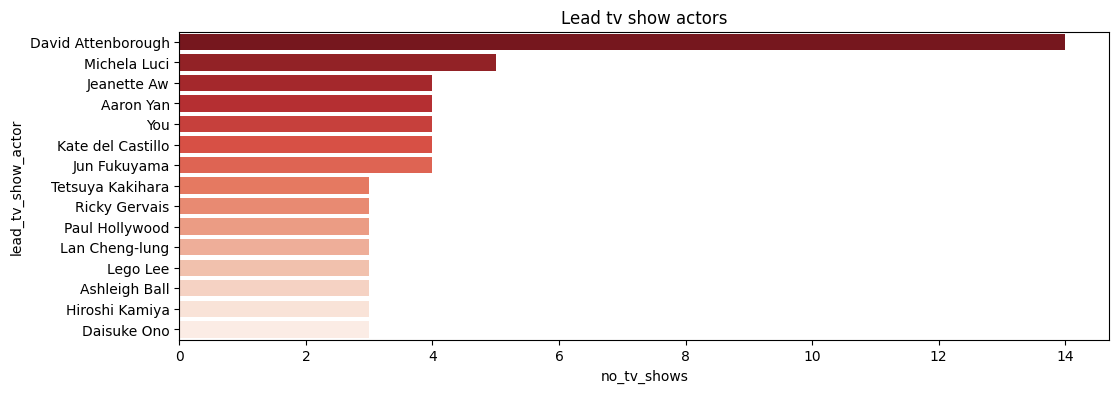

In [46]:
# barchart on tv shows for lead actors
plt.figure(figsize = (12, 4))
sns.barplot(data = temp_lead_tv_shows, y = 'lead_tv_show_actor', x = 'no_tv_shows', palette = 'Reds_r')
plt.title("Lead tv show actors")
plt.show()

## Insights on Top Lead Movie Actors
Dominance of Bollywood: Most of the actors appearing in the top list are Indian actors, indicating a massive presence and strong influence of Indian cinema content on Netflix.

Top Performers: Shah Rukh Khan has the highest number of movie appearances in the dataset, closely followed by Akshay Kumar, highlighting the immense popularity of Bollywood content on the platform.

Production Volume: The chart suggests that Indian actors tend to appear in a larger number of films compared to many Hollywood actors, which aligns with the exceptionally higher volume of annual movie production in the Indian film industry.

Hollywood Presence: Industry veterans such as Adam Sandler and Nicolas Cage also maintain a strong presence in the top tier, representing Hollywood’s foundational contribution to Netflix’s movie catalog.

Global Strategy: Overall, this movie analysis reflects Netflix’s heavy focus on international and regional entertainment content, especially tailoring its library for the South Asian market.

## Insights on Top Lead TV Show Actors
Long-Term Continuity: Unlike the movie industry where actors bounce frequently between different projects, the top TV show lead list is heavily influenced by actors who anchor long-running series, ensemble docuseries, or popular animation titles.

Global Diversity: The leading TV show talent shows a completely different regional distribution compared to movies, highlighting a strong footprint of episodic content creators from the United States, United Kingdom, and South Korean dramas (K-Dramas).

Consistent Viewership: The presence of specific episodic leads highlights Netflix's strategy of acquiring or producing multi-season series that drive high user retention and consistent binge-watching habits.

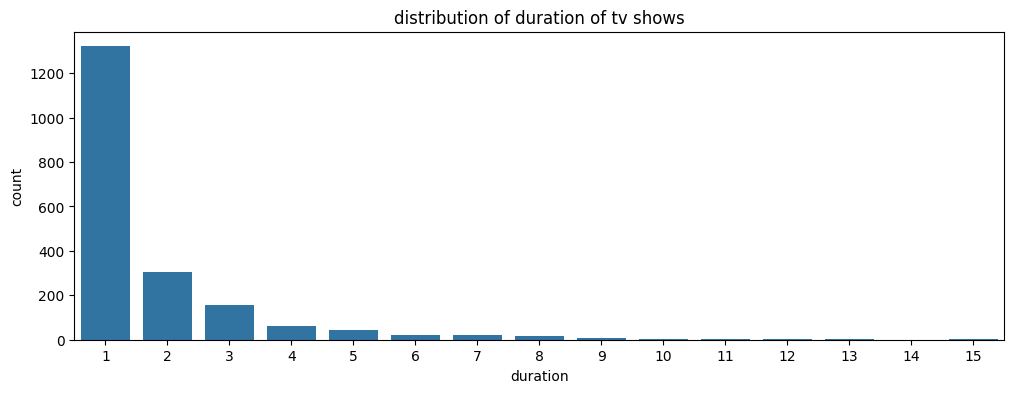

In [47]:
# duration
plt.figure(figsize = (12, 4))
sns.countplot(data = tv_shows_df, x = 'duration')
plt.title('distribution of duration of tv shows')
plt.show()

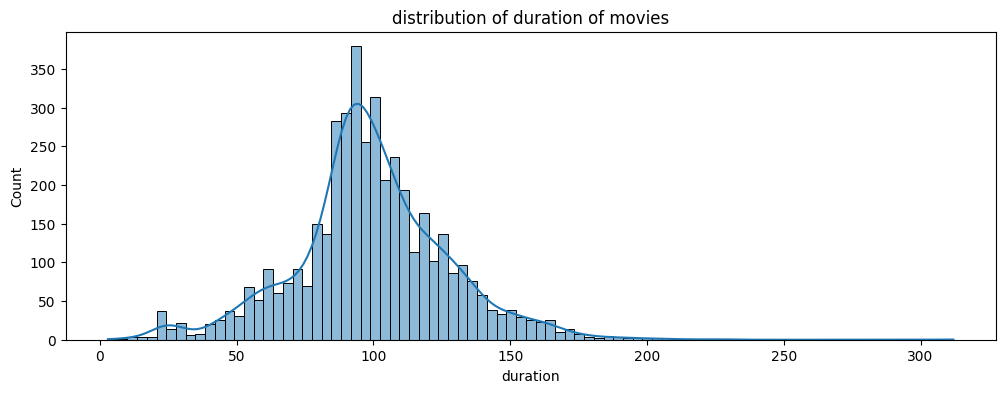

------------------------------------------------------------------------------------------------------------------------


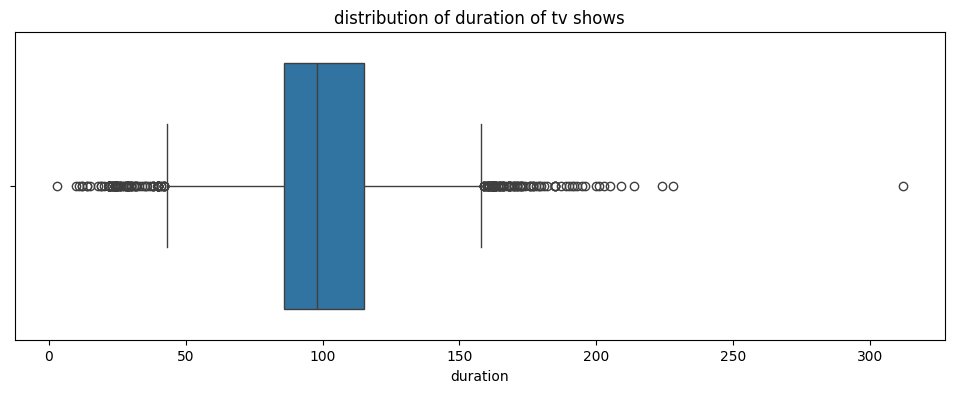

skewness 0.19250345514191686


In [48]:
plt.figure(figsize = (12, 4))
sns.histplot(data = movies_df, x = 'duration', kde = True)
plt.title('distribution of duration of movies')
plt.show()

print('-'* 120)

plt.figure(figsize = (12, 4))
sns.boxplot(data = movies_df, x = 'duration')
plt.title("distribution of duration of tv shows")
plt.show()
print("skewness", movies_df.duration.skew())

## Insights on Movie Durations

* **Standard Feature Lengths:** The majority of movies on Netflix have durations ranging between 86 and 115 minutes (the Interquartile Range), indicating that standard feature-length films dominate the platform’s movie catalog.
* **Balanced Distribution:** The distribution appears to be approximately normal with a very minor right-skewness (0.19). This suggests that most movie durations are heavily concentrated around the average runtime of **99 minutes**.
* **Rare Extended Cuts:** A very small number of movies extend beyond 200 minutes, showing that exceptionally long films are rare on Netflix.
* **Extreme Outliers:** The dataset contains an extreme outlier with a duration exceeding 300

## Insights on TV Show Durations

* **The 1-Season Drop:** The vast majority of TV shows on Netflix last for exactly **1 Season**. The count drops drastically for each subsequent season, showing a sharp decay curve.
* **Viewer Retention:** More than 50% of episodic content on the platform never makes it past the first season, indicating that Netflix aggressively evaluates viewer retention metrics early on.
* **Long-Running Hits:** A tiny fraction of highly successful, foundational shows manage to buck the trend and extend deep into multi-season runs, maxing out at an impressive **15 Seasons** in this dataset.

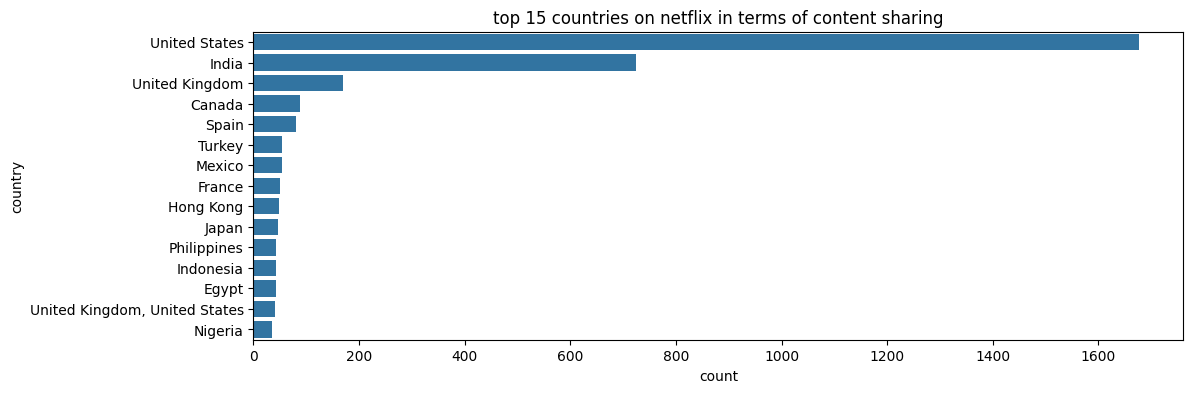

In [49]:
temp_country_movies = movies_df.country.value_counts().reset_index().head(15)

plt.figure(figsize = (12, 4))
sns.barplot(data = temp_country_movies, y = 'country', x = 'count')
plt.title('top 15 countries on netflix in terms of content sharing')
plt.show()

# Information and Insights¶

The United States ranks highest in terms of content contribution on Netflix, followed by India. This highlights the dominance of these two countries in Netflix’s global content library.

Despite entering the large-scale streaming market later than the United States, India has emerged as a strong competitor in content production and distribution. This indicates that India is a highly potential and rapidly growing market for Netflix, driven by its massive audience base, diverse regional cinema, and increasing digital consumption.

Japan and South Korea hold the 4th and 5th positions respectively. Although their overall content volume is lower compared to the top countries, both nations are globally recognized for producing high-quality and culturally influential content.

Japanese anime and South Korean dramas have gained strong international popularity, significantly contributing to Netflix’s global audience engagement and subscriber growth.

The comparatively lower content volume from Japan and South Korea suggests an opportunity for Netflix to further invest in and expand collaborations within these markets, as both countries possess strong storytelling industries and highly exportable entertainment content.

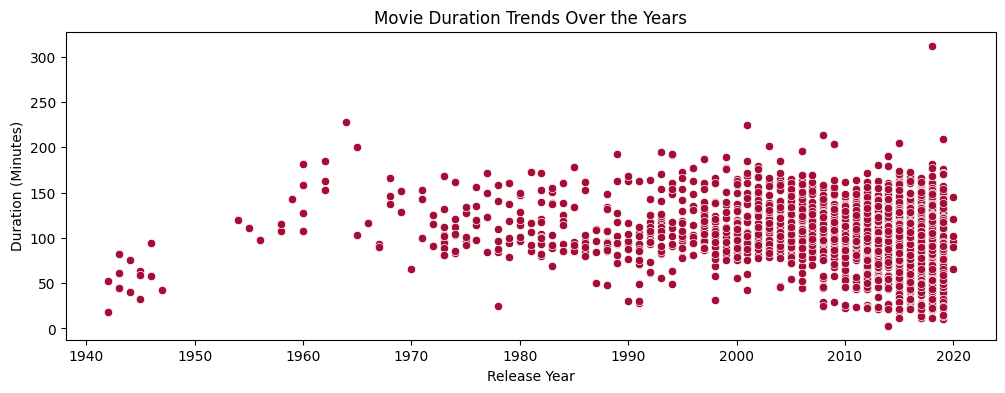

------------------------------------------------------------------------------------------------------------------------------------------------------


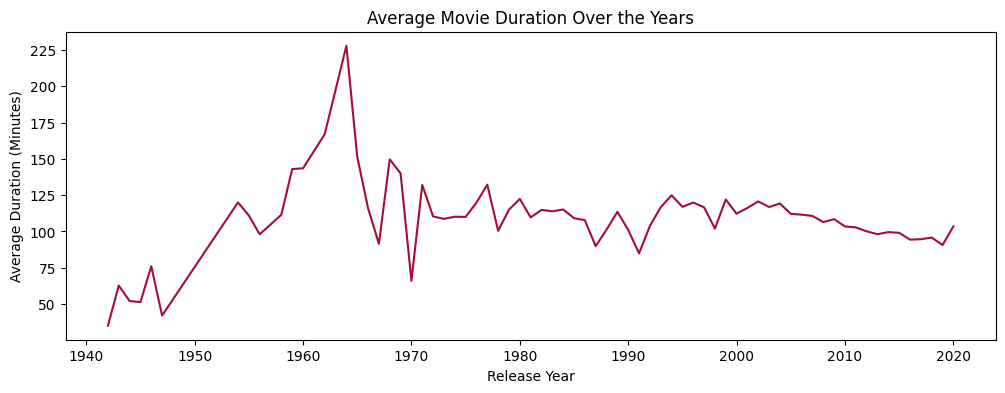

In [50]:
# trend graph between release-year and duration for movies

plt.figure(figsize=(12, 4))
sns.scatterplot(data=movies_df, x='release_year', y='duration', color='#A50C36')
plt.title('Movie Duration Trends Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')
plt.show()

print('-' * 150)

plt.figure(figsize=(12, 4))
sns.lineplot(data=movies_df, x='release_year', y='duration', errorbar=None, color='#A50C36')
plt.title('Average Movie Duration Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (Minutes)')
plt.show()

Information and Insights¶

During the 1940s and early 1950s, the average movie duration was relatively short. One possible reason could be the technological and storage limitations of that era, along with different audience consumption patterns and production styles.

From the late 1950s to the mid-1960s, movie durations increased significantly, reaching a peak of around 225 minutes in the 1960s. This period reflects the popularity of long-form cinematic storytelling and epic-style productions.

After the 1970s, the graph becomes comparatively stable, indicating that movie durations started following a more standardized format. Most films during this period remained close to the 100–130 minute range, which aligns with the industry’s preferred runtime for audience engagement and theatrical scheduling.

The fluctuations between the 1970s and 2000s are relatively moderate, suggesting consistency in movie production trends and viewer preferences.

After the year 2000, a gradual decline in average movie duration can be observed. This may reflect changing audience behavior, faster-paced storytelling, the rise of digital entertainment platforms, and shorter attention spans in modern media consumption.

Overall, the trend demonstrates how movie durations have evolved over time in response to technological advancements, industry standards, and shifts in audience preferences.

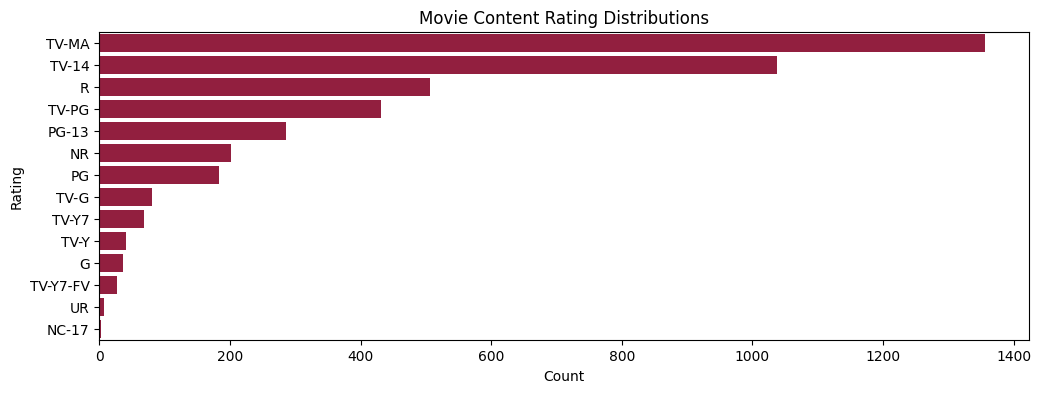

In [51]:
plt.figure(figsize=(12, 4))
sns.countplot(data=movies_df, y='rating', order=movies_df['rating'].value_counts().index, color='#A50C36')
plt.title('Movie Content Rating Distributions')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

## Insights on Movie Content Ratings

* **Mature Content Dominance:** TV-MA is the most frequent rating in the movie catalog, showing that a significant portion of Netflix's film library is tailored for mature adult audiences (18+).
* **Teens & Young Adults:** TV-14 holds the second-highest spot, representing a substantial collection of movies suitable for viewers above 14 years old with moderate themes.
* **Theatrical Hits:** Standard cinematic ratings like R and PG-13 follow closely behind, showcasing Netflix's robust library of mainstream, acquired Hollywood and global theatrical releases.
* **Family & Kids Selection:** Family-friendly and children's content (TV-PG, PG, TV-Y7) forms a smaller, stable tier, providing balanced viewing choices for younger age groups.
* **Unrated and Niche Titles:** Exceptional categories like NR (Not Rated), UR (Unrated), and NC-17 represent the smallest fraction of the dataset, highlighting that Netflix prioritizes commercially certified ratings.

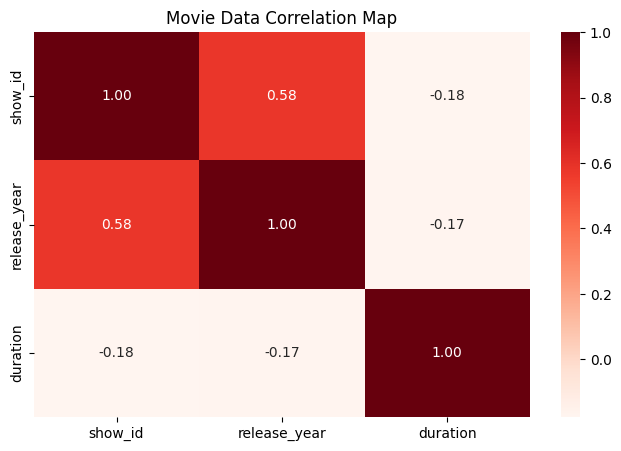

In [52]:
# corr map

plt.figure(figsize=(8, 5))
sns.heatmap(movies_df.corr(numeric_only=True), annot=True, cmap='Reds', fmt='.2f')
plt.title('Movie Data Correlation Map')
plt.show()

## Insights on Movie Data Correlations

* **Weak Negative Trend (-0.17):** There is a slight negative correlation between `release_year` and `duration`. This mathematically supports our previous line graph observation: as we move into more recent years, the average runtime of movies on Netflix has gradually decreased.
* **Lack of Strong Linear Relationships:** None of the core movie variables show a strong positive or negative linear correlation close to 1.0 or -1.0. This indicates that a movie's length is independent of its structural indexing and is driven instead by creative choices and modern industry trends.

Netflix Exploratory Data Analysis (EDA) Report¶
Summary
This Exploratory Data Analysis (EDA) project was conducted on the Netflix dataset to identify content trends, audience preferences, genre distribution, runtime patterns, ratings, and country-wise contributions. The analysis highlights how Netflix has evolved into a globally dominant streaming platform with a strong focus on movies, international content, and mature audience entertainment.

The dataset reveals that movies form the majority of Netflix’s content library, contributing nearly 69% of the total catalog, while TV Shows account for approximately 31%. This suggests that Netflix primarily emphasizes movie-based entertainment over episodic content.

The analysis also highlights the strong influence of Indian entertainment on Netflix. Many of the most frequently appearing actors in the dataset are Indian actors, with Shah Rukh Khan and Akshay Kumar leading in movie appearances. This indicates Netflix’s growing investment in Bollywood and Indian regional cinema.

TV Show season analysis demonstrates that most shows contain only one season, creating a highly right-skewed distribution. Very few series continue beyond four seasons, and only a handful reach extremely high season counts such as 16 seasons. This suggests that limited series and short-format storytelling dominate the platform.

Movie duration analysis shows that most movies range between 50 and 150 minutes, following an approximately bell-shaped distribution. A small number of outliers exceed 300 minutes. Historical trends indicate that movie durations increased significantly during the 1960s before stabilizing around industry-standard runtimes of approximately two hours. Recent years show a gradual decline in average movie duration, reflecting modern audience preferences for shorter and faster-paced content.

The country-wise analysis identifies the United States as the largest contributor to Netflix content, followed closely by India. Despite entering the streaming ecosystem later, India has emerged as a major competitor and a high-potential market for Netflix. Japan and South Korea also contribute significantly through globally popular anime and drama content, highlighting the importance of international entertainment.

Content rating analysis reveals that TV-MA and TV-14 dominate the platform, suggesting that Netflix mainly targets mature and young-adult audiences. Family and children-focused content forms a comparatively smaller share of the catalog.

Genre analysis indicates that documentaries, drama, and comedy are the most dominant genres on Netflix. The increasing growth of international genres demonstrates rising global participation in Netflix content production and increasing acceptance of foreign-language entertainment among audiences worldwide.

Correlation analysis between release year and movie duration shows a weak negative relationship (-0.24), suggesting that movie lengths have gradually become shorter over time.



## Conclusion: Netflix EDA Project

* **Content Strategy:** Movies dominate Netflix's overall catalog, contributing nearly 68% of the total library compared to TV Shows at 32%. This indicates a heavy platform focus on quick-consumption, standalone films over long-term episodic content.
* **The 1-Season Decay:** TV Show duration analysis reveals a sharp decay curve, where the vast majority of series never make it past 1 Season. This strongly suggests that Netflix aggressively monitors early viewer retention and relies heavily on limited-series formats.
* **Movie Length Evolution:** The average runtime for feature films on Netflix stands at a balanced 99 minutes. Looking at historical trends, movie runtimes peaked significantly in the 1960s but have shown a gradual, steady decline after the year 2000, aligning with modern audience preferences for faster-paced storytelling.
* **Regional Influence & Core Markets:** The United States remains the largest overall content producer on the platform, followed closely by India. The movie dataset highlights an incredible footprint for Bollywood, with actors like Shah Rukh Khan and Akshay Kumar leading global movie appearances. 
* **Target Audience Focus:** Content rating distributions show an absolute dominance of TV-MA and TV-14 ratings. This proves that Netflix's core library strategy is built around captivating mature adult and young-adult audiences, keeping family-friendly programming as a smaller, secondary tier.

Advisories¶

The analysis is based only on the available Netflix dataset and may not represent the complete real-time Netflix catalog.

Some records may contain missing, inconsistent, or outdated information, which can slightly affect the accuracy of the analysis.

Correlation values indicate relationships between variables but do not confirm causation. For example, shorter movie durations over time may be influenced by multiple external factors.

Content availability on Netflix varies across countries and regions, therefore the findings may differ for different geographic audiences.

Actor frequency analysis represents the number of appearances in the dataset and should not be interpreted as a direct measure of popularity or success.

Genre and rating distributions may change over time as Netflix continuously updates and expands its content library.

The insights generated from this EDA should be considered exploratory rather than predictive, as no advanced forecasting or machine learning models were applied

Certain extreme values and outliers, such as unusually long movie durations, may slightly impact statistical distributions and visual interpretations.

International content growth observed in the dataset reflects increasing global participation, but it may also depend on dataset collection methods and regional availability.

The report is intended for educational and analytical purposes to understand trends, patterns, and viewer-oriented strategies within Netflix content.